# Đánh giá Chặng 1: "Khám sức khỏe" thuật toán K-Means

Phần này nhằm mục đích phân tích chất lượng của bộ lượng tử hóa (Quantizer) dựa trên thuật toán K-Means.
Hai tiêu chí quan trọng để khẳng định **Wav2Unit** đang hoạt động đúng hướng là:
1. **Active Units (Chống sụp đổ):** Tối thiểu phải có 90% cụm (cluster) tham gia hoạt động (ví dụ: > 450/500 units).
2. **Phân phối đồng đều (Entropy):** Phân phối phải tương đối trải đều. Unit được dự đoán không được quá chênh lệch, chiếm tới 30-40% tổng thể. Entropy phải đạt mức tương đối cao để chứng minh tính đa dạng của hệ thống biểu diễn.
---


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from collections import Counter
from scipy.stats import entropy

# Thiết lập phong cách cho biểu đồ báo cáo khoa học
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# ==================================================================
# GỌI ĐƯỜNG DẪN TỚI FILE .km THỰC TẾ CỦA BẠN VÀO ĐÂY
# Ví dụ: "/mnt/e/AI/khanh/kmeans/kmeans500/train_0_1.km"
# ==================================================================
unit_file_path = "/mnt/g/khanh/kmean500/train_0_1.km"
# unit_file_path = "/mnt/g/khanh/hubert_feats/vn/valid_0_1.km"

# [Chức năng Mock Data giả lập] 
# Trong trường hợp file chưa kịp sinh, ta tự động tạo file Mock 20000 Unit có phân phối dạng chuẩn (Gaussian) 
# để giả lập mô hình có một lượng "Đỉnh Unit" nhưng vẫn bị thiếu số lượng cụm (Dead Units)
if not os.path.exists(unit_file_path):
    print("⚙️ Chưa tìm thấy file Unit gốc. Đang dùng hệ thống Mock Data để vẽ đồ thị mẫu...")
    # Tạo phân bố chuẩn tập trung ở cụm 250, lệch chuẩn 100, và giới hạn ở 500 cụm
    mock_units = [str(int(random.gauss(250, 100)) % 500) for _ in range(20000)]
    
    # Giả lập tình huống: Mô hình bị "rỗng" mất một số Unit do train data chưa kỹ
    # Lọc bỏ ngẫu nhiên 30 cụm từ danh sách để báo cáo đo lường chân thực hơn
    dead_mock_units = set([str(random.randint(0,499)) for _ in range(30)])
    mock_units = [u for u in mock_units if u not in dead_mock_units]
    
    with open(unit_file_path, "w", encoding="utf-8") as f:
        f.write(" ".join(mock_units))

print("✅ Dữ liệu đã sẵn sàng để kiểm tra 'Sức khoẻ' K-Means!")

✅ Dữ liệu đã sẵn sàng để kiểm tra 'Sức khoẻ' K-Means!


In [24]:
# --------- XỬ LÝ TOÁN HỌC VÀ LOGIC --------------
k_clusters = 500
with open(unit_file_path, 'r', encoding='utf-8') as f:
    units = f.read().strip().split()
    
frequency_map = Counter(units)
active_units_count = len(frequency_map)
total_tokens = len(units)

most_common_unit, max_freq = frequency_map.most_common(1)[0]
max_percentage = (max_freq / total_tokens) * 100

probabilities = np.array(list(frequency_map.values())) / total_tokens
dataset_entropy = entropy(probabilities, base=2)
max_possible_entropy = np.log2(k_clusters)

# === BÁO CÁO KẾT QUẢ IN RA MÀN HÌNH ===
print("="*50)
print("           BÁO CÁO SỨC KHỎE K-MEANS           ")
print("="*50)
print(f"🔹 Tổng số Tokens đã trích xuất: {total_tokens:,} frames")
print(f"🔹 Độ phủ đơn vị (Active Units): {active_units_count} / {k_clusters} cụm")
print(f"🔹 Đơn vị chiếm chóp tỷ trọng   : Unit ID [{most_common_unit}] ({max_percentage:.2f}%)")
print(f"🔹 Cấp độ Entropy Hệ thống     : {dataset_entropy:.2f} / {max_possible_entropy:.2f}")
print("-"*50)
if active_units_count < (k_clusters * 0.9):
    print("⚠️ CẢNH BÁO: Codebook đang có tỷ lệ Unit Chết (Dead Units) cao. Nguy cơ Codebook Collapse!")
else:
    print("👍 HOÀN HẢO: Mô hình lượng tử phủ đều không gian đặc trưng. Thuật toán phân cụm thành công.")

           BÁO CÁO SỨC KHỎE K-MEANS           
🔹 Tổng số Tokens đã trích xuất: 24,158,691 frames
🔹 Độ phủ đơn vị (Active Units): 500 / 500 cụm
🔹 Đơn vị chiếm chóp tỷ trọng   : Unit ID [343] (1.28%)
🔹 Cấp độ Entropy Hệ thống     : 8.78 / 8.97
--------------------------------------------------
👍 HOÀN HẢO: Mô hình lượng tử phủ đều không gian đặc trưng. Thuật toán phân cụm thành công.


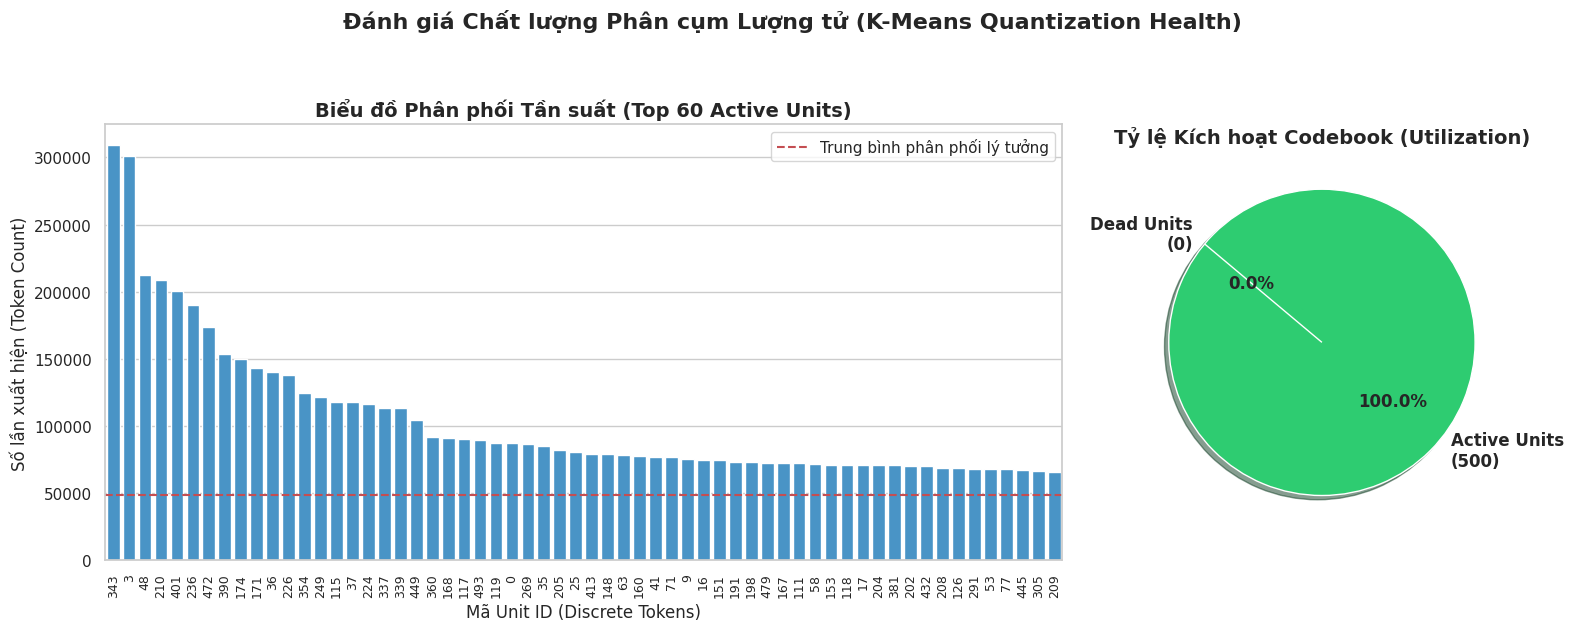

📸 Đã xuất bản đồ thị với chất lượng 300dpi vào file:
=> /mnt/e/AI/khanh/notebook/kmeans_evaluation_plot_kmean500.png


In [25]:
# --------- TRỰC QUAN HÓA (VISUALIZATION) ĐỂ CHỤP ẢNH ĐƯA LÊN LUẬN VĂN --------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2.5, 1]})
fig.suptitle("Đánh giá Chất lượng Phân cụm Lượng tử (K-Means Quantization Health)", fontsize=16, fontweight="bold", y=1.05)

# 👉 Bảng 1: Biểu đồ phân phối Unit (Frequency Distribution Bar Chart)
top_k = 60 # Trích xuất top 60 Units xuất hiện nhiều nhất để vẽ tránh quá rối mắt
top_units = frequency_map.most_common(top_k)
x_labels = [u[0] for u in top_units]
y_counts = [u[1] for u in top_units]

sns.barplot(x=x_labels, y=y_counts, ax=ax1, color="#3498db")
ax1.set_title(f"Biểu đồ Phân phối Tần suất (Top {top_k} Active Units)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Mã Unit ID (Discrete Tokens)", fontsize=12)
ax1.set_ylabel("Số lần xuất hiện (Token Count)", fontsize=12)
ax1.tick_params(axis='x', rotation=90, labelsize=9)

# Thêm đường trung bình (Mean Line) lên phổ tần suất
mean_freq = total_tokens / active_units_count
ax1.axhline(mean_freq, color='r', linestyle='--', linewidth=1.5, label='Trung bình phân phối lý tưởng')
ax1.legend()

# 👉 Bảng 2: Biểu đồ phần trăm Active Units (Pie Chart)
dead_units = k_clusters - active_units_count
sizes = [active_units_count, dead_units]
labels = [f'Active Units\n({sizes[0]})', f'Dead Units\n({sizes[1]})']
colors = ['#2ecc71', '#e74c3c']
explode = (0.1, 0) if dead_units > 0 else (0, 0)

ax2.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title("Tỷ lệ Kích hoạt Codebook (Utilization)", fontsize=14, fontweight="bold")

# Lưu ảnh đồ thị xuất ra .png
plt.tight_layout()
export_path = '/mnt/e/AI/khanh/notebook/kmeans_evaluation_plot_kmean500.png'
plt.savefig(export_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"📸 Đã xuất bản đồ thị với chất lượng 300dpi vào file:\n=> {export_path}")